In [75]:
import sys
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from tqdm.auto import tqdm

**确定参数**

In [76]:
股票代码 = '600000'
start_date = "20240306"
end_date = '20250328'
Default_Strategy = 'strategy_3d'
split_ratio = 0.7
window_size = 35  # 滚动窗口的观察区间
decay_factor = 1  # 衰减因子，控制权重衰减速度

mean_reversion_params = {
    'sma_window': 6,
    'threshold': 1,
    'safety_weight' : 1,
    'position_col': 'mean_reversion_position'
}

**导入并整理数据**

In [77]:
source_data = ak.stock_zh_a_hist(symbol=股票代码,period="daily",start_date=start_date,end_date=end_date,adjust='')

In [78]:
data = pd.DataFrame()
data['date'] = source_data['日期']
data['price'] = source_data['收盘']
data['volume'] = source_data['成交量']
data['returns']=np.log(data['price']/data['price'].shift(1))
data['returns_cum'] = np.exp(data['returns'].cumsum())
data.set_index('date', inplace=True)
data.dropna()

,price,volume,returns,returns_cum
date,,,,
2024-03-07,7.14,246903,0.002805,1.002809
2024-03-08,7.12,198618,-0.002805,1.000000
2024-03-11,7.11,261955,-0.001405,0.998596
2024-03-12,7.10,290305,-0.001407,0.997191
2024-03-13,7.04,259485,-0.008487,0.988764
...,...,...,...,...
2025-03-24,10.61,464497,0.013283,1.490169
2025-03-25,10.61,378754,0.000000,1.490169
2025-03-26,10.47,366610,-0.013283,1.470506


**分割训练集**

In [79]:
total_dates = data.index.nunique()
split_index = int(total_dates *split_ratio)
split_date = data.index.unique()[split_index]
train = data[:split_date].copy()
test = data[split_date:].copy()

**构建函数**

In [80]:
def automas_by_mean(df, window_size, decay_factor, Default_Strategy, mean_reversion_params=None):
    """
    结合动量策略和均值回归策略的自动交易系统
    修改后的组合策略在均值回归信号为0时只使用动量策略信号
    """

    # 2. 动量策略部分
    for days in range(1, 23):
        df[f'position_{days}d'] = np.where(df['returns'].rolling(days).mean() > 0, 1, -1)
        df[f'strategy_{days}d'] = df[f'position_{days}d'].shift(1) * df['returns']
        df[f'sty_cumr_{days}d'] = df[f'strategy_{days}d'].cumsum() + 1
    
    # 3. 均值回归策略部分
    sma_window = mean_reversion_params['sma_window']
    threshold = mean_reversion_params['threshold']
    position_col = mean_reversion_params['position_col']
    safety_weight = mean_reversion_params['safety_weight']
    
    df['SMA'] = df['price'].rolling(sma_window).mean()
    df['distance'] = df['price'] - df['SMA']
    
    df[position_col] = np.nan
    df[position_col] = np.where(df['distance'] > threshold, -1, df[position_col])
    df[position_col] = np.where(df['distance'] < -threshold, 1, df[position_col])
    df[position_col] = np.where(df['distance'] * df['distance'].shift(1) < 0, 0, df[position_col])
    df[position_col] = df[position_col].fillna(0)
    
    df['mean_reversion_returns'] = df[position_col].shift(1) * df['returns']
    
    # 4. 动量策略选择部分
    strategy_return_columns = [f'strategy_{days}d' for days in range(1, 23)]
    all_strategy_returns = df[strategy_return_columns].copy()
    
    weights = np.array([decay_factor ** (window_size - i - 1) for i in range(window_size)])
    weights = weights / weights.sum()
    
    best_strategy_by_mean_return = []
    
    for i in range(len(all_strategy_returns)):
        if i < window_size:
            current_window = all_strategy_returns.iloc[:i+1]
            current_weights = weights[window_size - (i+1):]
            current_weights = current_weights / current_weights.sum()
        else:
            current_window = all_strategy_returns.iloc[i-window_size:i]
            current_weights = weights
        
        if not current_window.empty:
            mean_returns = (current_window * current_weights[:, np.newaxis]).sum()
            best_strat = mean_returns.idxmax()
        else:
            best_strat = Default_Strategy
        best_strategy_by_mean_return.append(best_strat)
    
    df['best_strategy_mean_return'] = best_strategy_by_mean_return
    
    # 5. 应用最佳动量策略
    df['auto_strategy_mean_return_position'] = np.nan
    df['auto_strategy_mean_return'] = np.nan
    
    
    for days in range(1, 23):
        mask = df['best_strategy_mean_return'] == f'strategy_{days}d'
        df.loc[mask, 'auto_strategy_mean_return_position'] = df.loc[mask, f'position_{days}d']
        df['auto_strategy_mean_return'] = df['returns'] * df['auto_strategy_mean_return_position'].shift(1)
    switch_dates = df[df['best_strategy_mean_return'] != df['best_strategy_mean_return'].shift(1)].index
    
    for date in switch_dates:
        curr_days = int(df.loc[date, 'best_strategy_mean_return'].split('_')[1][:-1])
        df.loc[date, 'auto_strategy_mean_return_position'] = df.loc[date, f'position_{curr_days}d']
    
    # 6. 修改后的组合策略 - 只在均值回归有信号时使用
    # 创建权重数组：当均值回归信号为0时权重为0，否则为0.5
    mean_rev_weight = np.where(df[position_col] == 0, 0, safety_weight)
    momentum_weight = np.where(df[position_col] == 0, 1, 1-safety_weight)
    
    # 确保组合策略计算正确（当mean_rev信号为0时完全等于动量策略）
    df['combined_position'] = np.where(
        df[position_col] == 0,
        df['auto_strategy_mean_return_position'],
        (1-safety_weight)*df['auto_strategy_mean_return_position'] + safety_weight*df[position_col]
    )
    df['combined_returns'] = df['combined_position'].shift(1) * df['returns']
    
    # 7. 返回结果
    return df[[
        'auto_strategy_mean_return_position', 
        position_col, 
        'combined_position', 
        'auto_strategy_mean_return', 
        'mean_reversion_returns', 
        'combined_returns',
        'best_strategy_mean_return'  # 新增返回最佳策略列
    ]]

In [81]:
def gra_analyze(df):
    # Set English fonts and style
    plt.style.use('seaborn-v0_8')
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.unicode_minus'] = False
    
     
    # ======================
    # 0. 新增：价格与移动平均线距离图
    # ======================
    plt.figure(figsize=(25, 6))
    
    # 计算SMA和距离（如果尚未计算）
    if 'SMA' not in df.columns:
        df['SMA'] = df['price'].rolling(mean_reversion_params['sma_window']).mean()
    if 'distance' not in df.columns:
        df['distance'] = df['price'] - df['SMA']
    
    # 绘制距离线
    df['distance'].dropna().plot(label='Price - SMA Distance', color='blue')
    
    # 绘制阈值线
    plt.axhline(mean_reversion_params['threshold'], color='red', linestyle='--', label='Upper Threshold')
    plt.axhline(-mean_reversion_params['threshold'], color='red', linestyle='--', label='Lower Threshold')
    plt.axhline(0, color='black', linestyle='-', alpha=0.5, label='SMA Line')
    
    # 标记交易信号点
    buy_signals = df[df['mean_reversion_position'] == 1]
    sell_signals = df[df['mean_reversion_position'] == -1]
    
    plt.scatter(buy_signals.index, buy_signals['distance'], 
               color='green', marker='^', s=100, label='Buy Signal')
    plt.scatter(sell_signals.index, sell_signals['distance'],
               color='red', marker='v', s=100, label='Sell Signal')
    
    plt.title('Price-SMA Distance with Trading Signals')
    plt.ylabel('Distance from SMA')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 1. Trading Position Plots (for all three strategies)
    # ======================
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(25, 9), sharex=True)
    
    # Momentum strategy position
    ax1.plot(df['auto_strategy_mean_return_position'], color='blue')
    ax1.set_title('Momentum Strategy Position (1=Long, -1=Short)')
    ax1.set_ylabel('Position')
    ax1.set_ylim([-1.1, 1.1])
    ax1.grid(True)
    
    # Mean reversion strategy position
    ax2.plot(df['mean_reversion_position'], color='green')
    ax2.set_title('Mean Reversion Strategy Position (1=Long, -1=Short)')
    ax2.set_ylabel('Position')
    ax2.set_ylim([-1.1, 1.1])
    ax2.grid(True)
    
    # Combined strategy position
    ax3.plot(df['combined_position'], color='purple')
    ax3.set_title('Combined Strategy Position')
    ax3.set_ylabel('Position')
    ax3.set_ylim([-1.1, 1.1])
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 2. Performance Metrics (for all three strategies)
    # ======================
    metrics = pd.DataFrame()
    
    # Calculate metrics for each strategy
    strategies = {
        'Momentum': 'auto_strategy_mean_return',
        'MeanReversion': 'mean_reversion_returns',
        'Combined': 'combined_returns'
    }
    
    for name, col in strategies.items():
        mean_return = df[col].mean()
        std_dev = df[col].std()
        
        metrics.loc[name, 'Mean'] = mean_return
        metrics.loc[name, 'StdDev'] = std_dev
        
        # 修正Sharpe比率的计算方式
        if std_dev != 0:  # 直接比较标量值而不是Series
            metrics.loc[name, 'Sharpe'] = mean_return / std_dev
        else:
            metrics.loc[name, 'Sharpe'] = np.nan
            
        metrics.loc[name, 'TotalReturn'] = df[col].sum()
        
        # Calculate max drawdown
        cumret = df[col].cumsum().apply(np.exp)
        cummax = cumret.cummax()
        max_drawdown = (cummax - cumret).max()
        metrics.loc[name, 'MaxDrawdown'] = max_drawdown
    
    # ======================
    # 3. Price/Volume Plots (using combined strategy signals)
    # ======================
    # Use threshold to determine clear signals
    buy = df[df['combined_position'] > 0.5]  # Strong long signals
    sell = df[df['combined_position'] < -0.5]  # Strong short signals
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(25, 12))
    
    # Price plot
    ax1.plot(df['price'], label='Price', color='black', alpha=0.8)
    ax1.scatter(buy.index, buy['price'], color='red', label='Buy Signal (Combined)', marker='^', s=100)
    ax1.scatter(sell.index, sell['price'], color='green', label='Sell Signal (Combined)', marker='v', s=100)
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True)
    
    # Volume plot
    ax2.bar(df.index, df['volume'], color='gray', alpha=0.3, label='Volume')
    ax2.bar(buy.index, buy['volume'], color='red', label='Buy Volume')
    ax2.bar(sell.index, sell['volume'], color='green', label='Sell Volume')
    ax2.set_ylabel('Volume')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle('Price and Volume with Combined Strategy Signals', y=0.92)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 4. Cumulative Returns Comparison
    # ======================
    plt.figure(figsize=(25, 8))
    
    # Calculate cumulative returns
    df['momentum_cumret'] = df['auto_strategy_mean_return'].cumsum().apply(np.exp)
    df['meanrev_cumret'] = df['mean_reversion_returns'].cumsum().apply(np.exp)
    df['combined_cumret'] = df['combined_returns'].cumsum().apply(np.exp)
    df['buyhold_cumret'] = df['returns'].cumsum().apply(np.exp)
    
    plt.plot(df['momentum_cumret'], label='Momentum Strategy', color='blue')
    plt.plot(df['meanrev_cumret'], label='Mean Reversion Strategy', color='green')
    plt.plot(df['combined_cumret'], label='Combined Strategy', color='purple', linewidth=3)
    plt.plot(df['buyhold_cumret'], label='Buy & Hold', color='gray', linestyle='--')
    
    plt.title('Cumulative Returns Comparison')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 5. Comprehensive Strategy Comparison
    # ======================
    plt.figure(figsize=(25, 12))
    
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    
    # Price plot
    ax1.plot(df['price'], label='Price', color='black', alpha=0.7)
    
    # Strategy returns
    ax2.plot(df['combined_cumret'], 
             label='Combined Strategy', 
             color='purple',
             linewidth=3,
             zorder=3)
    
    ax2.plot(df['momentum_cumret'], 
             label='Momentum Strategy', 
             color='blue',
             linewidth=2,
             linestyle='--',
             alpha=0.7,
             zorder=2)
    
    ax2.plot(df['meanrev_cumret'], 
             label='Mean Reversion Strategy', 
             color='green',
             linewidth=2,
             linestyle=':',
             alpha=0.7,
             zorder=2)
    
    # Trading zones based on combined strategy
    ax1.fill_between(df.index, 
                    df['price'].min()*0.98, 
                    df['price'].max()*1.02,
                    where=(df['combined_position']>0),
                    color='green', alpha=0.05, label='Long Zone')
    ax1.fill_between(df.index,
                     df['price'].min()*0.98,
                     df['price'].max()*1.02,
                     where=(df['combined_position']<0),
                     color='red', alpha=0.05, label='Short Zone')
    
    ax1.set_ylabel('Price')
    ax2.set_ylabel('Cumulative Returns')
    
    plt.title('Comprehensive Strategy Performance Comparison', pad=20)
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    # Combine legends
    handles, labels = [], []
    for ax in [ax1, ax2]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    plt.legend(handles, labels, loc='upper left', ncol=3)
    
    plt.tight_layout()
    plt.show()
    
    print("Performance Metrics:")
    print(metrics.round(4))

**参数优化**

In [85]:
# 定义搜索空间
space = [
    Integer(1, 23, name='sma_window'),
    Real(0.1, 2, name='threshold'),
    Real(0.2, 0.8, name='safety_weight'),
    Integer(20, 50, name='window_size'),
    Real(0.8, 1.2, name='decay_factor'),
    Categorical([f'strategy_{d}d' for d in range(1, 23)], name='Default_Strategy') 
]

# 创建全局进度条
pbar = tqdm(total=50, desc="贝叶斯优化进度")
best_score = -np.inf
best_params = None

# 自定义回调函数
def callback(res):
    global best_score, best_params, pbar
    
    current_score = -res.fun  # 转换为正夏普比率
    if current_score > best_score:
        best_score = current_score
        best_params = dict(zip(
            ['sma_window', 'threshold', 'safety_weight', 'window_size', 'decay_factor', 'Default_Strategy'],
            res.x
        ))
    
    pbar.update(1)
    pbar.set_postfix({
        '当前最佳夏普': f"{best_score:.4f}",
        'sma_window': best_params['sma_window'] if best_params else None,
        'threshold': f"{best_params['threshold']:.2f}" if best_params else None
    })


# 修改目标函数以捕获异常
def objective(params):
    try:
        sma_w, thresh, safety, w_size, decay, default = params
        
        mean_reversion_params.update({
            'sma_window': int(sma_w),
            'threshold': float(thresh),
            'safety_weight': float(safety)
        })
        
        automas_by_mean(train, int(w_size), float(decay), default, mean_reversion_params)
        
        returns = train['combined_returns'].dropna()
        if len(returns) < 2:
            return 1000  # 惩罚无效参数
        
        sharpe = returns.mean() / returns.std()
        return -sharpe  # 最小化负夏普
    
    except Exception as e:
        print(f"参数 {params} 执行失败: {str(e)}")
        return 1000

# 运行优化（添加回调）
n_calls = 50  # 总迭代次数
res = gp_minimize(
    objective,
    space,
    n_calls=n_calls,
    random_state=0,
    callback=callback,  # 添加进度条回调
    verbose=False  # 保留原始输出
)

# 关闭进度条
pbar.close()

# 输出最佳参数
best_params = dict(zip(
    ['sma_window', 'threshold', 'safety_weight', 'window_size', 'decay_factor', 'Default_Strategy'],
    res.x
))
print("\n优化完成！最佳参数组合：")
for k, v in best_params.items():
    print(f"{k:>15}: {v}")
print(f"夏普比率: {-res.fun:.4f}")

贝叶斯优化进度:   0%|          | 0/50 [00:00<?, ?it/s]


优化完成！最佳参数组合：
     sma_window: 23
      threshold: 1.4515921559744867
  safety_weight: 0.704370852770922
    window_size: 41
   decay_factor: 1.1558284136330663
Default_Strategy: strategy_22d
夏普比率: 0.1848


In [86]:
Default_Strategy = best_params['Default_Strategy']
window_size = best_params['window_size']  # 滚动窗口的观察区间
decay_factor = best_params['decay_factor']  # 衰减因子，控制权重衰减速度
mean_reversion_params = {
    'sma_window': best_params['sma_window'],
    'threshold': best_params['threshold'],
    'position_col': 'mean_reversion_position', 
    'safety_weight' : best_params['safety_weight'],
}

**应用函数**

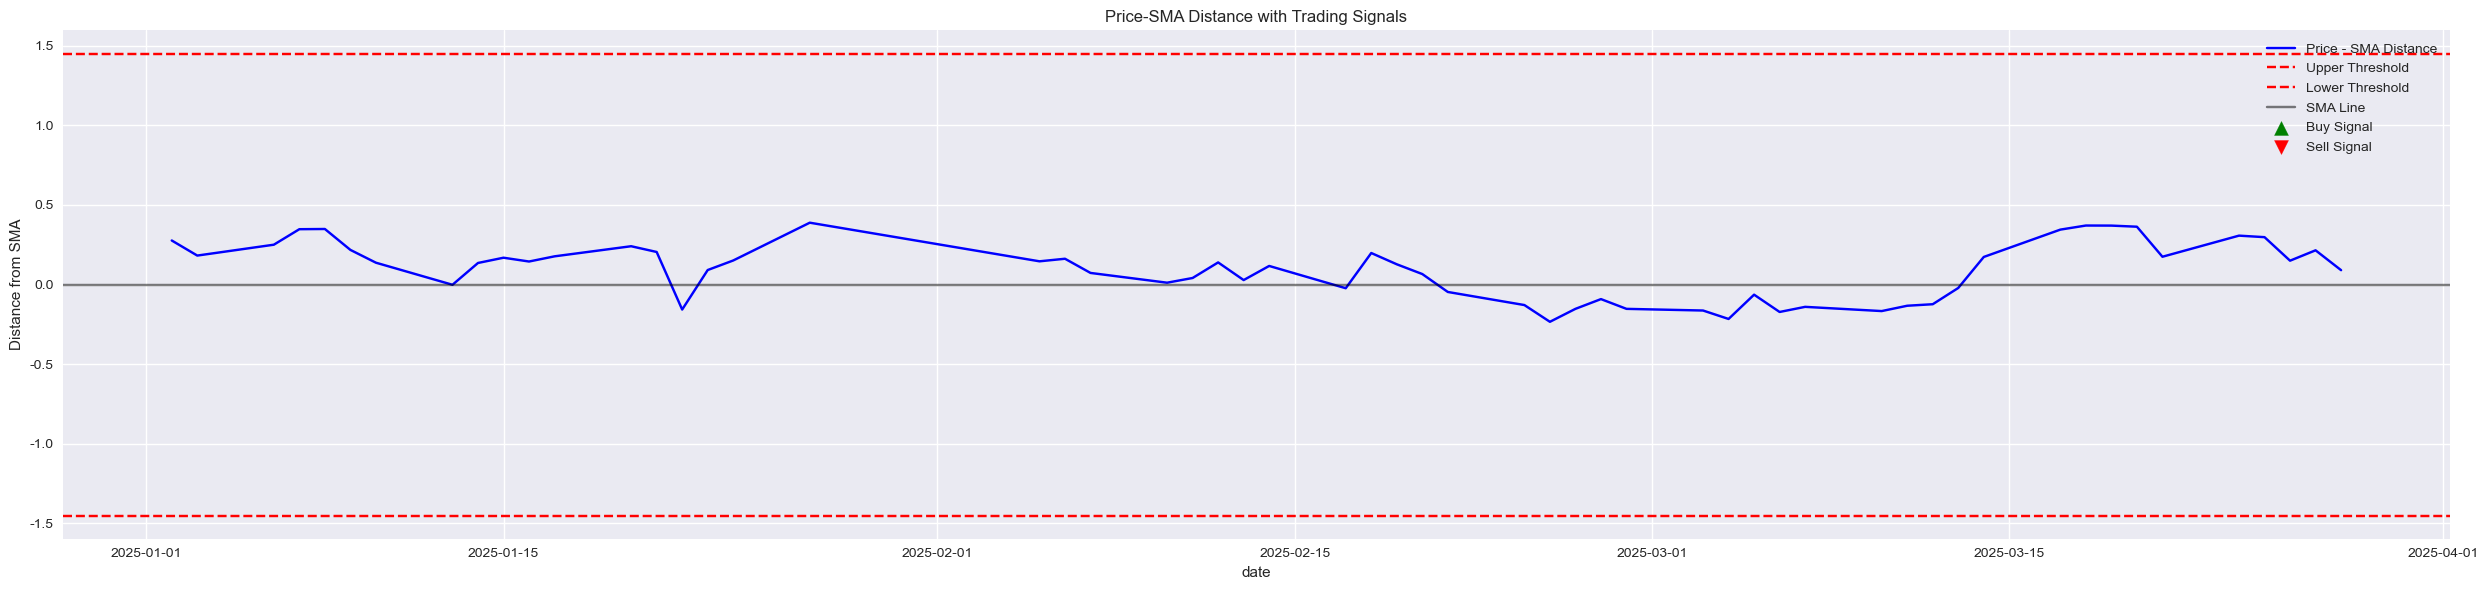

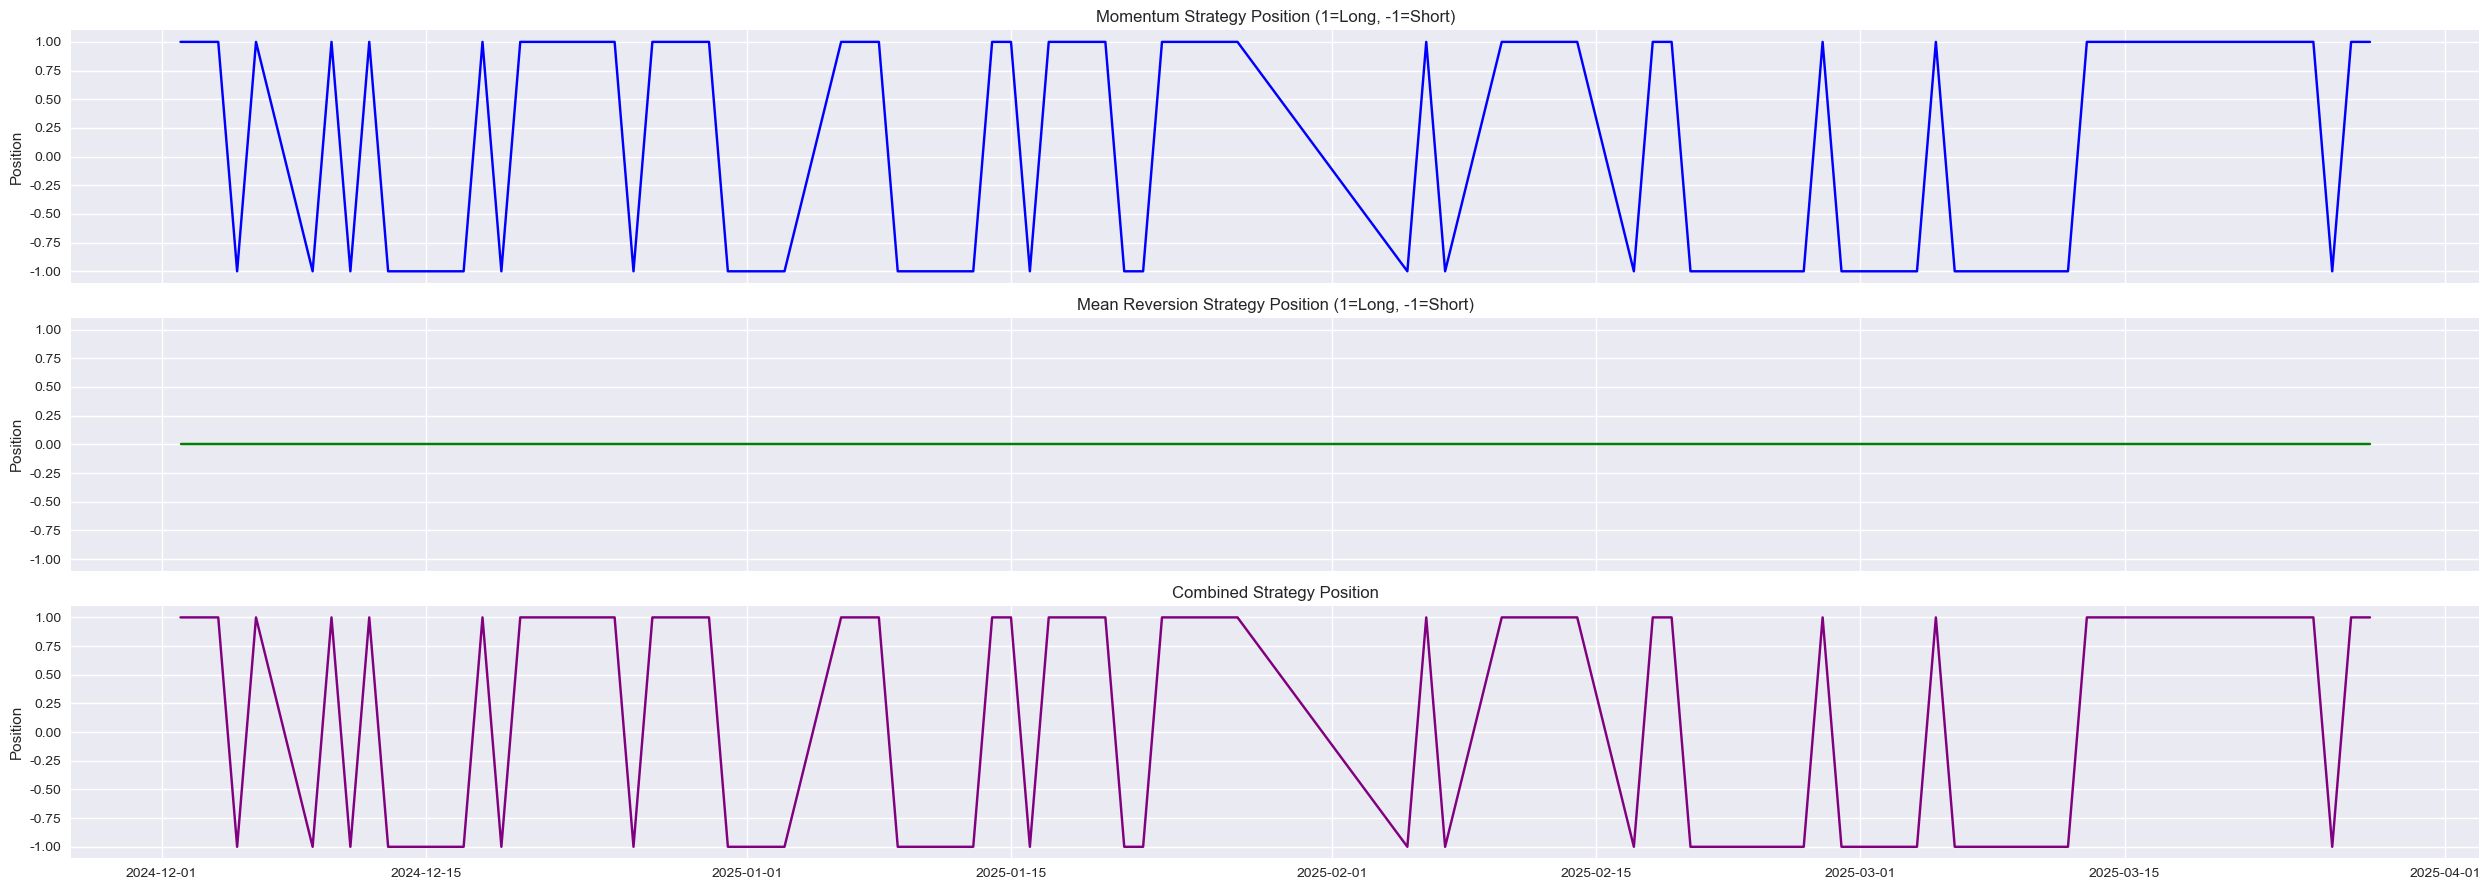

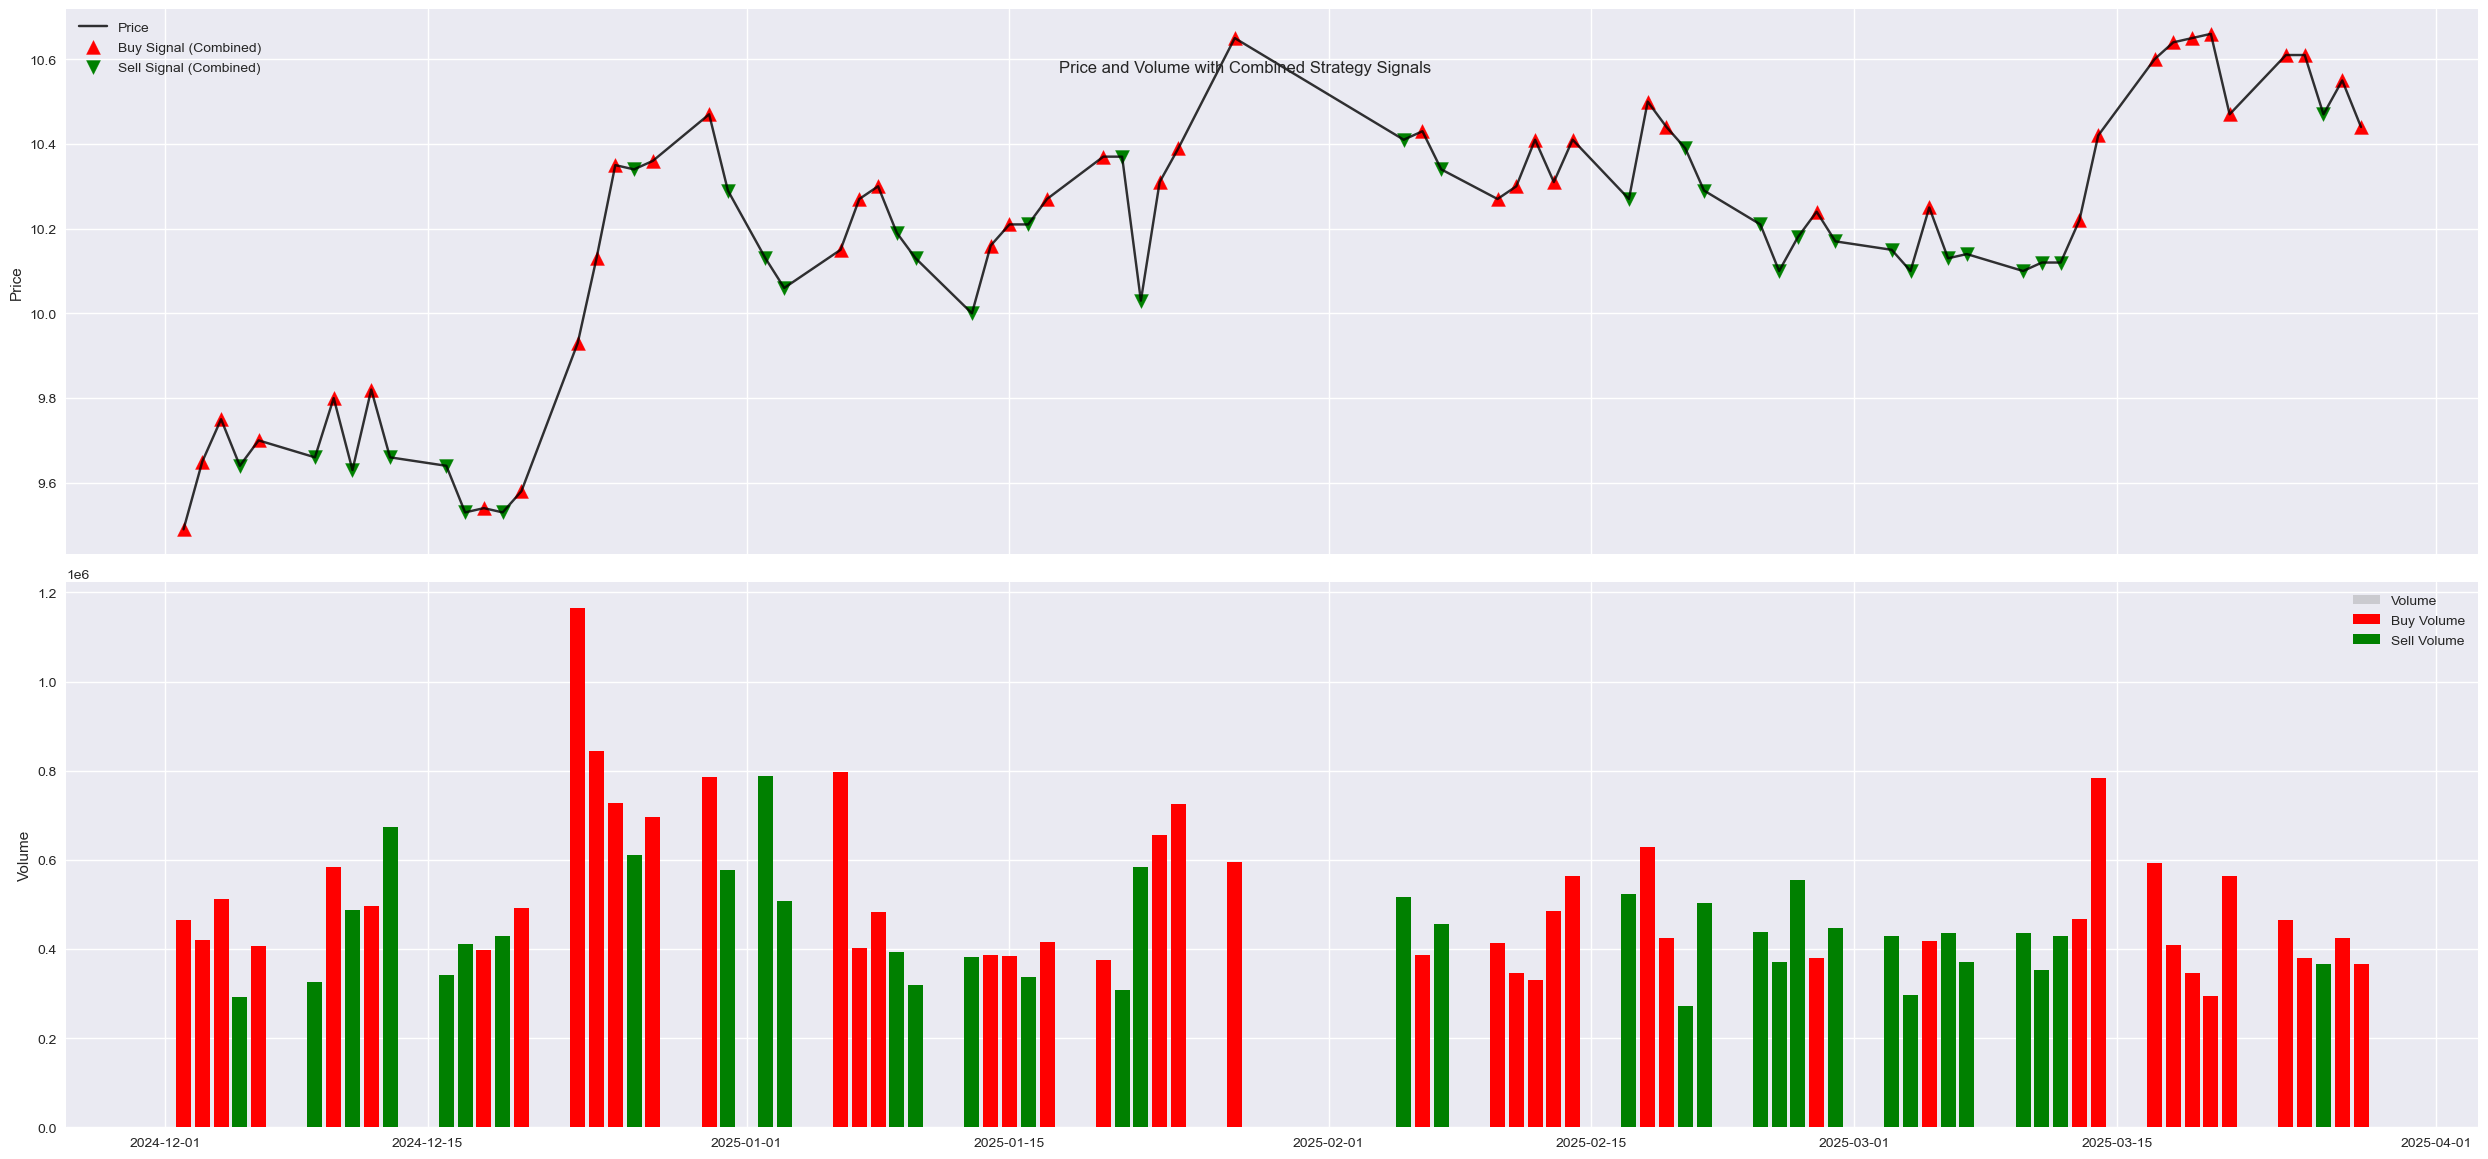

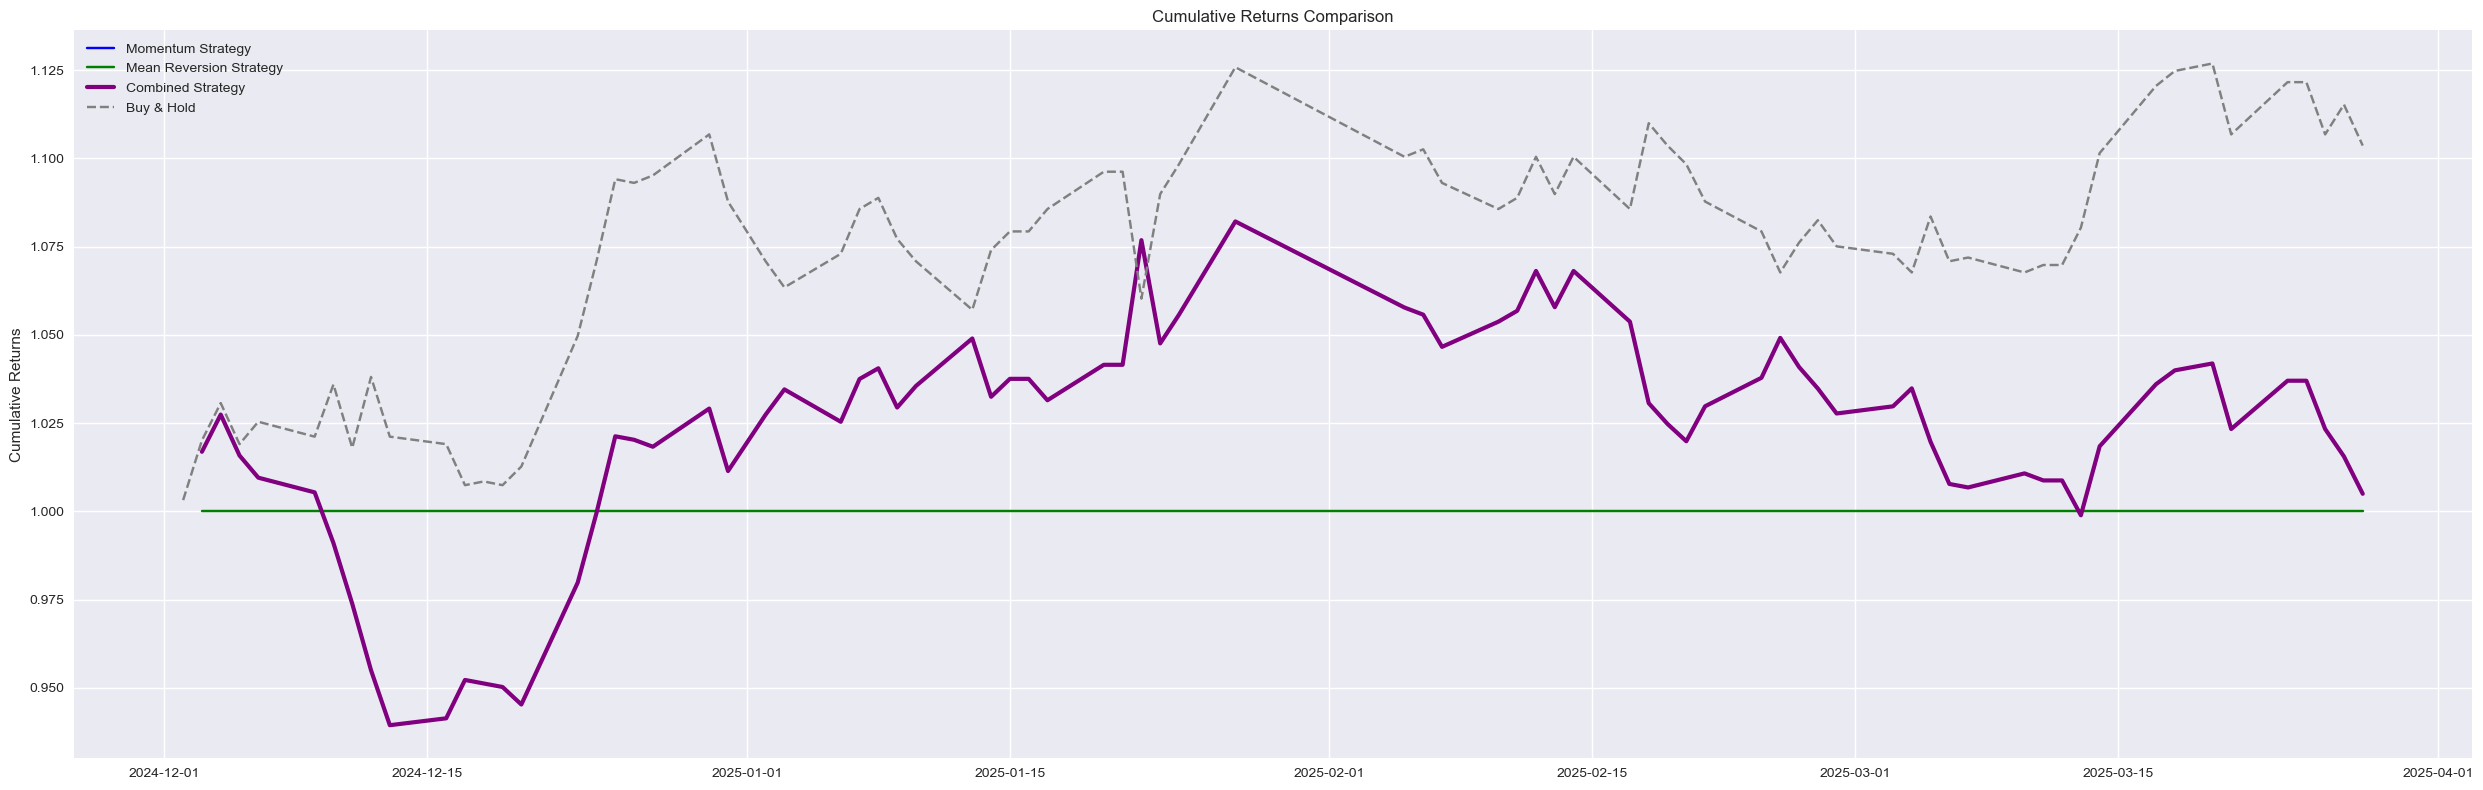

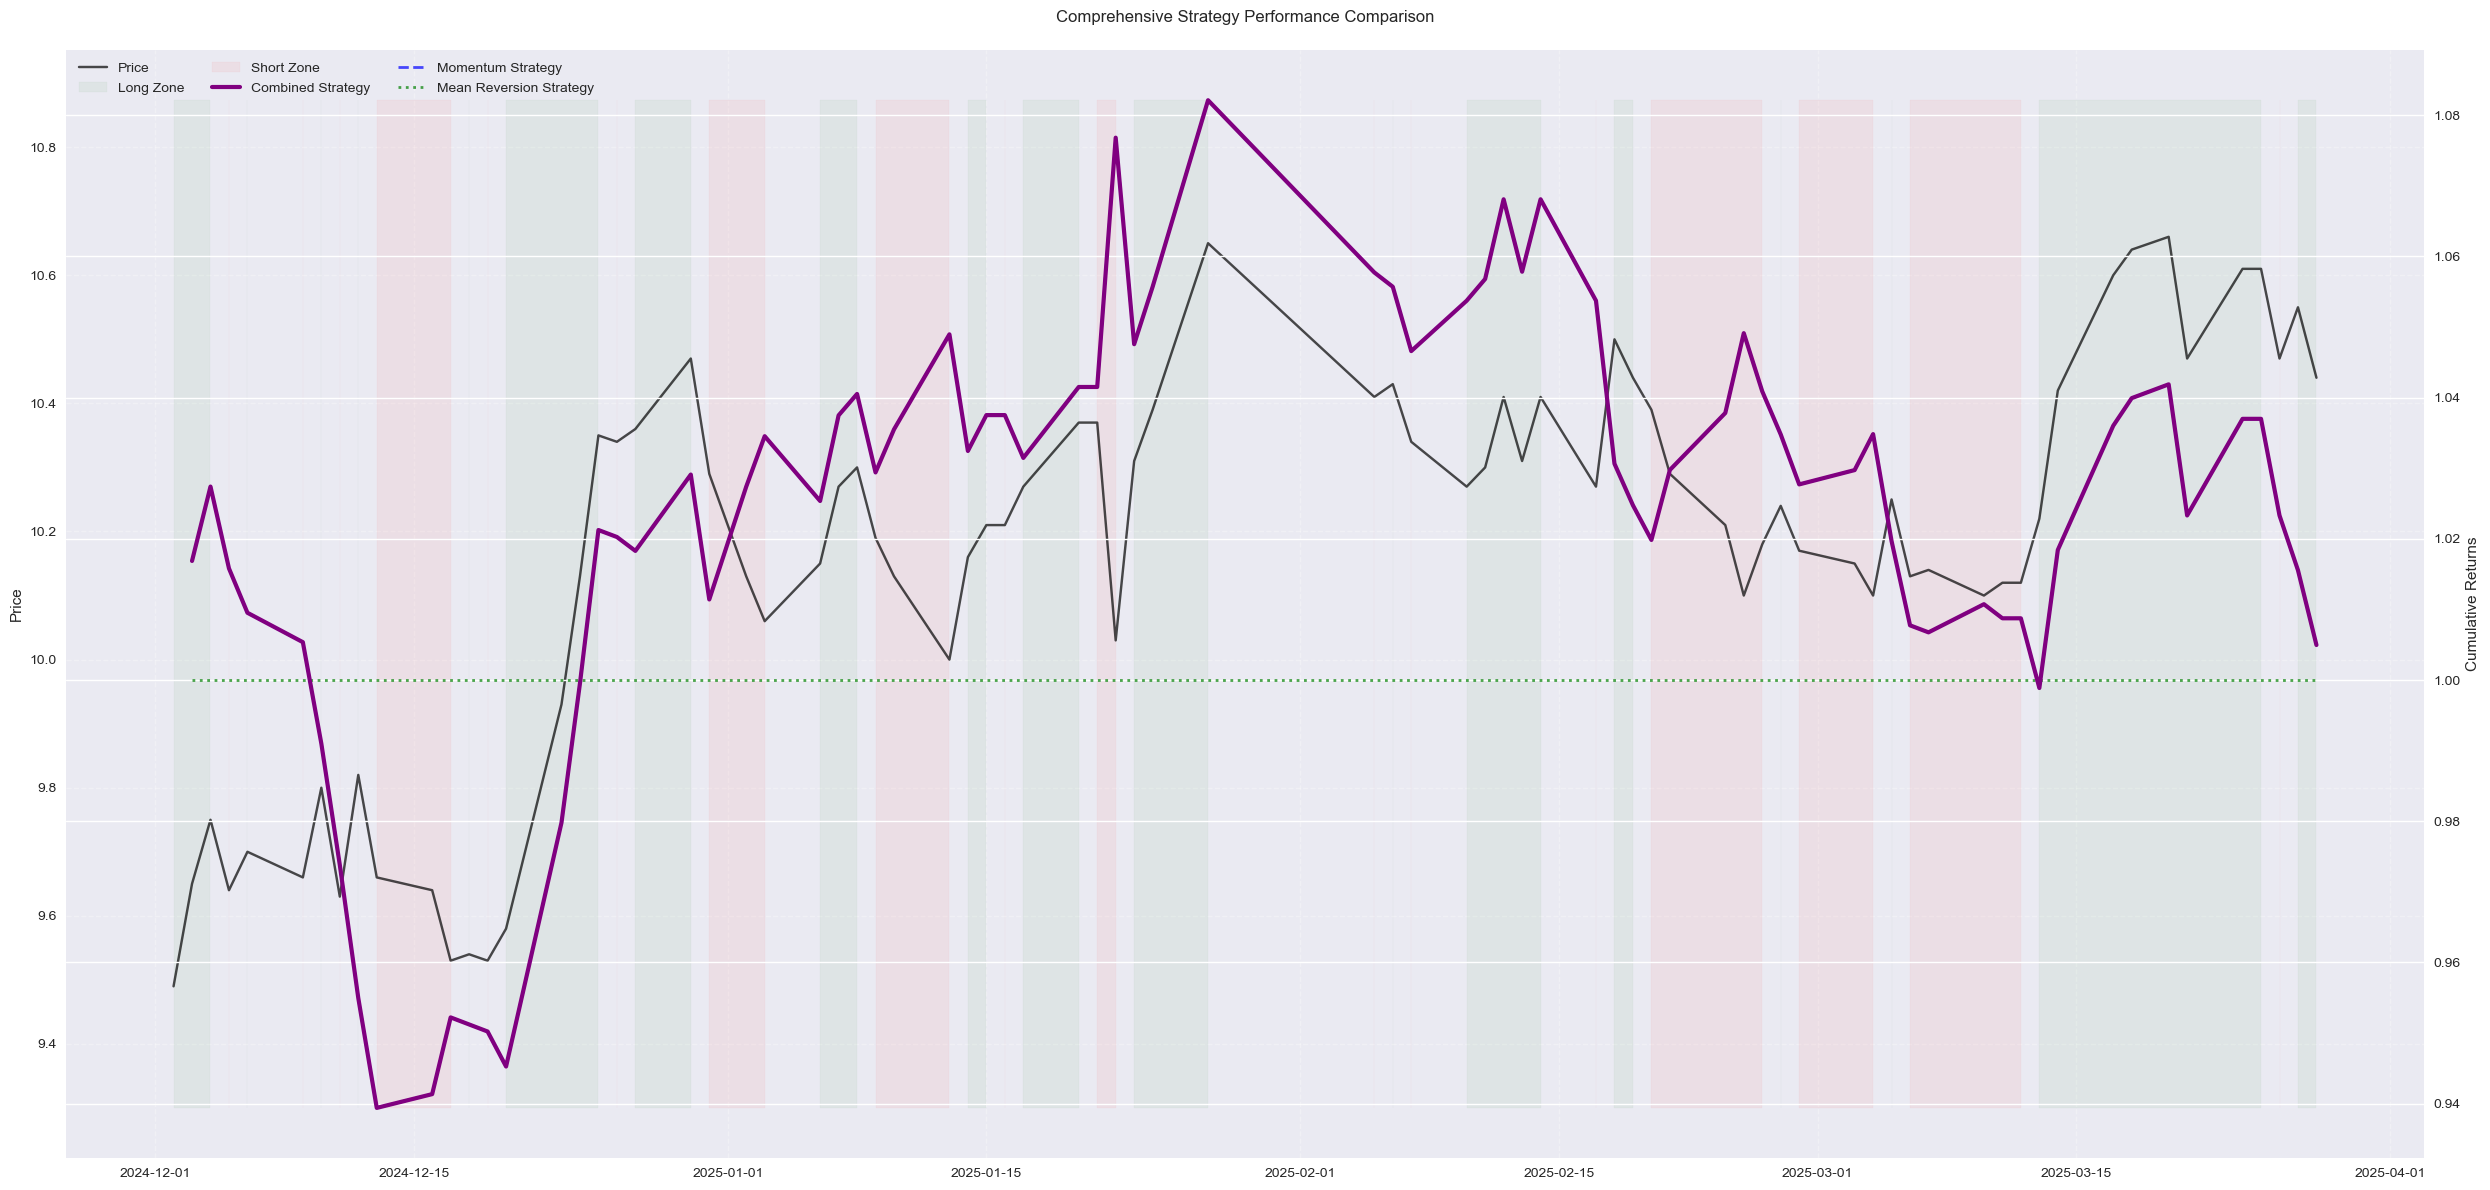

Performance Metrics:
                 Mean  StdDev  Sharpe  TotalReturn  MaxDrawdown
Momentum       0.0001  0.0128   0.005       0.0049        0.088
MeanReversion  0.0000  0.0000     NaN       0.0000        0.000
Combined       0.0001  0.0128   0.005       0.0049        0.088


In [87]:
automas_by_mean(test, window_size, decay_factor, Default_Strategy,mean_reversion_params)
gra_analyze(test)